In [183]:
from autoenkoop import *
import torch
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import os
import pydmd
from tqdm import tqdm
from matplotlib.colors import Normalize

DEVICE = "cuda"

In [244]:
data_path = os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz")
center_dataset = True
train_test_split = 0.7
train_data, test_data, temp_mean = load_and_prepare_data(data_path, center_dataset, train_test_split)

In [245]:
full_data = np.concatenate((train_data, test_data), axis=0)
prediction_window = 100
window_offset_data = full_data[:-prediction_window]

dataset_full = SimpleDataset(window_offset_data)

loader_full = DataLoader(dataset_full, batch_size=4, shuffle=False)

dataset_train = SimpleDataset(train_data)
loader_train = DataLoader(dataset_train, batch_size=4, shuffle=False)#, num_workers=2, pin_memory=True)

In [249]:
temp_mean_error = np.mean((full_data - temp_mean)**2, axis=(1,2,3))

In [251]:
temp_mean_error

array([0.9374629 , 0.93512404, 0.9338849 , ..., 1.0869305 , 1.0868763 ,
       1.0821607 ], shape=(1493,), dtype=float32)

In [211]:
train_test_cutoff = int(full_data.shape[0]*0.7)
print(train_test_cutoff)

1045


In [212]:
original_data = full_data + temp_mean

(vx_min, vx_max), (vz_min, vz_max) = get_min_max(original_data)
vx_absmax = max(abs(vx_min), abs(vx_max))*0.2
vz_absmax = max(abs(vz_min), abs(vz_max))*0.2
norm_x = Normalize(vmin=-vx_absmax, vmax=+vx_absmax)
norm_z = Normalize(vmin=-vz_absmax, vmax=+vz_absmax)

In [213]:
full_data = np.moveaxis(full_data, -1, 1)

In [194]:
#example_index = 0
#
#vx = original_data[example_index, :, :, 0]
#vz = original_data[example_index, :, :, 1]
#
#plot_vx_vz(vx, vz, norm_x, norm_z)
#animate_trajectory(np.moveaxis(original_data[0:50], -1, 1), "original", norm_x, norm_z)

In [195]:
def calculate_koopman(model, loader):
    Z = []
    with torch.no_grad():
        for x_t in loader:
            x_t = x_t.to(DEVICE)
            #encoded current state
            z_t = model.encoder(x_t) 
            Z.append(z_t.cpu().numpy())
    Z_all = np.vstack(Z).T
    dmd = pydmd.DMD(-1, forward_backward=False)
    dmd.fit(Z_all)
    K_star = (dmd.modes @ np.diag(dmd.eigs) @ np.linalg.pinv(dmd.modes)).real
    return K_star

In [196]:
def predict_window(x_t, model, linfunction, window_length):
    with torch.no_grad():
        z_t = model.encoder(x_t)
                
        window_prediction = []
        x_t_predicted = model.decoder(z_t).cpu().numpy()
        window_prediction.append(x_t_predicted)
                
        for i in range(window_length):
            z_t = linfunction(z_t)
            x_t_predicted = model.decoder(z_t).cpu().numpy()
            window_prediction.append(x_t_predicted)
                
    return np.vstack(window_prediction)

L128_e300_lr2e-4_lamlin1_train


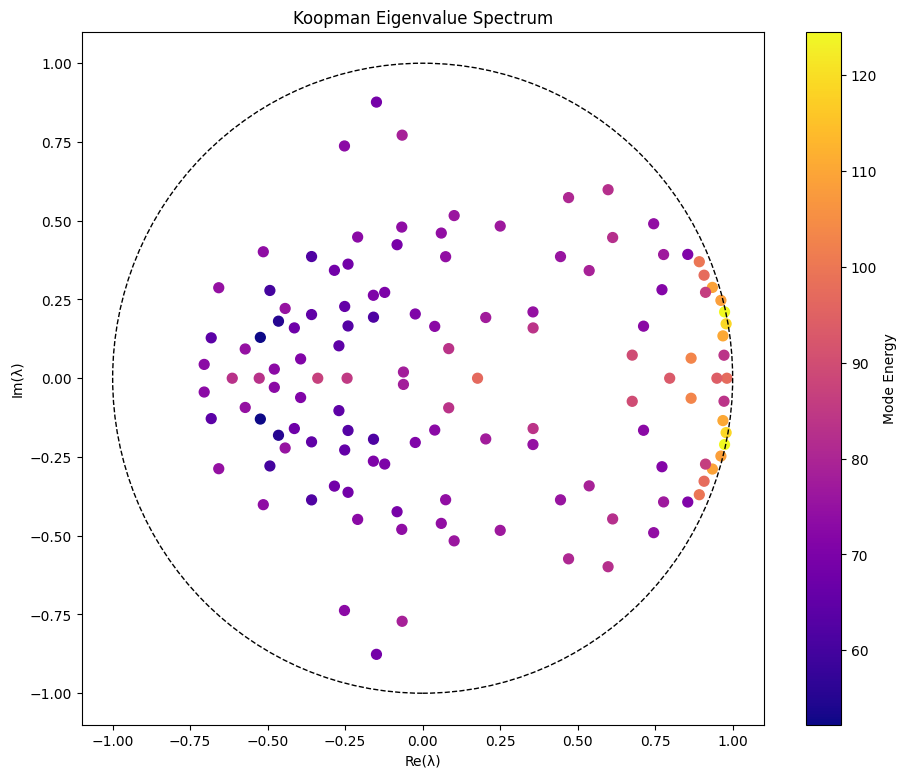

L128_e300_lr2e-4_lamlin1_dmd


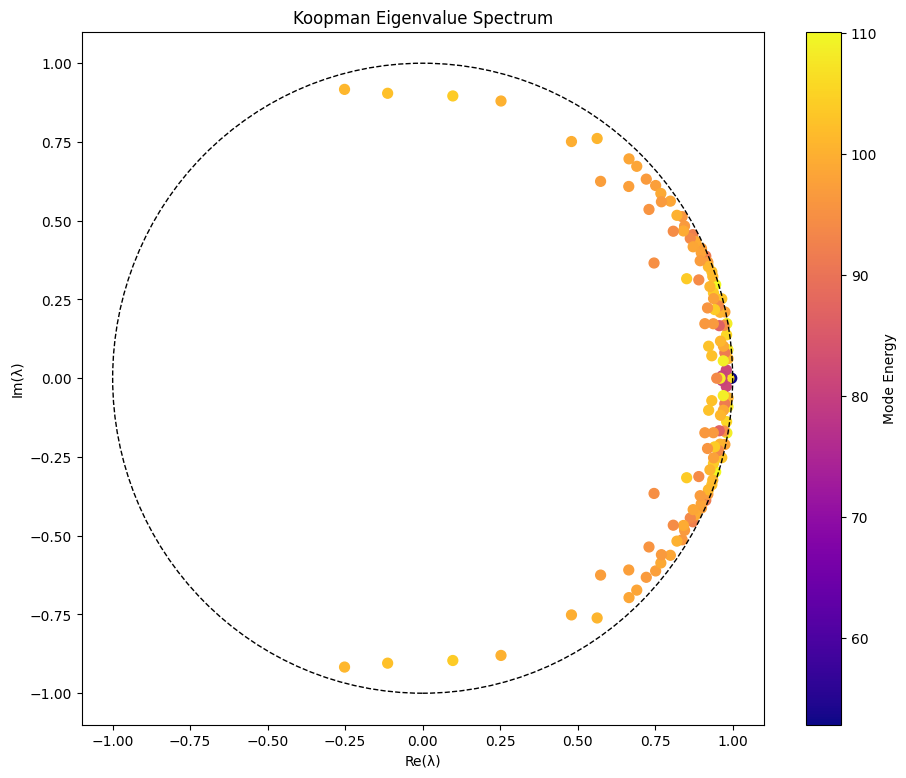

In [278]:
results_path = os.path.join("..", "results")
run_name_list = [
    #"L128_e300_lamlin1_train",
    "L128_e300_lr2e-4_lamlin1_train",
    #"L32_e300_lamlin1_dmd",
    #"L32_e300_lamlin10_dmd",
    #"L128_e300_lamlin10_dmd",
    #"L32_e300_lr0.0002_K0Dec_equalW_dmd",
    #"L32_e300_lamlin1_lrgroup",
    #"L32_e300_lamlin10_lrgroup",
    #"L32_e300_lr2e-4_lamlin10_dmd",
    #"L32_e300_lr2e-4_lamlin1_dmd",
    "L128_e300_lr2e-4_lamlin1_dmd"
    ]

prediction_mse_windows = []

for run_name in run_name_list:
    print(run_name)
    run_path = os.path.join(results_path, "kae_experiments", run_name)
    
    hyperparam = run_name.split('_')
    
    LATENT_DIM = int(hyperparam[0][1:])
    koopman_type = hyperparam[-1]
    
    model = ConvAutoencoderZeroDecoder(latent_dim=LATENT_DIM).to(DEVICE)
    
    model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))
    model.eval()

    if koopman_type == "dmd":
        K = calculate_koopman(model, loader_train)
        lin_weights = torch.tensor(K, device=DEVICE, requires_grad=True)
        linfunction = lambda z_t : torch.nn.functional.linear(z_t, lin_weights)
    else:
        linfunction = lambda z_t : model.linear_dynamics(z_t)
        with torch.no_grad():
            K = model.linear_dynamics.weight.detach().cpu().numpy()
    
    eigvalues, eigvectors = get_sorted_eigen(K)
    eigenergies = eigenvalue_energies(model, eigvectors, DEVICE)
    plot_eigenvalue_spectrum(eigvalues, eigvectors, eigenergies)
    
    prediction_window_path = os.path.join(run_path,"pred_window_mse.npy")
    if os.path.exists(prediction_window_path):
        prediction_mse = np.load(prediction_window_path)
    else:
        prediction_mse = np.zeros((window_offset_data.shape[0], prediction_window+1))
        with torch.no_grad():
            for j, x_t in tqdm(enumerate(dataset_full), total=len(dataset_full)):
                x_t = x_t.to(DEVICE).unsqueeze(0)
                #X_prediction = predict_window(x_t, model, linfunction, prediction_window)
                z_t = model.encoder(x_t)
            
                window_prediction = []
                x_t_predicted = model.decoder(z_t).cpu().numpy()
                window_prediction.append(x_t_predicted)
            
                for i in range(prediction_window):
                    z_t = linfunction(z_t)
                    x_t_predicted = model.decoder(z_t).cpu().numpy()
                    window_prediction.append(x_t_predicted)
                
                X_prediction = np.vstack(window_prediction)
                mse_window = np.mean((full_data[j:j+prediction_window+1] - X_prediction)**2, axis=(1,2,3))
                prediction_mse[j] = mse_window
            #    mse_test = torch.mean((x_t - x_t_predicted)**2, dim=(1,2,3)).cpu().numpy()
            #    window_mse.append(mse_test)
        np.save(prediction_window_path[:-4], prediction_mse)
    prediction_mse_windows.append(prediction_mse)
    #        
    #
    
    #
    #break

In [279]:
def filter_pos_imag(values, vectors, energies):
    mode_mask = values.imag >= 0
    mode_vectors = vectors[:, mode_mask]
    mode_values = values[mode_mask]
    mode_energies = energies[mode_mask]
    return mode_values, mode_vectors, mode_energies

def calculate_eigenmode_structures(eigenvectors, model, device = "cpu"):
    modes = []
    with torch.no_grad():
        for vec in eigenvectors.T:
            modes.append(model.decoder(torch.FloatTensor(vec.real).unsqueeze(0).to(device)).squeeze(0).cpu().numpy())
    return modes

In [ ]:
mode_values, mode_vectors, mode_energies = filter_pos_imag(eigvalues, eigvectors, eigenergies)
stable_structures = calculate_eigenmode_structures(mode_vectors, model, device=DEVICE)
for i, structure in enumerate(stable_structures):
    print(mode_values[i].item(),"\t", np.abs(mode_values[i].item()))
    print(mode_energies[i])
    vx = structure[0,:]
    vz = structure[1,:]
    plot_vx_vz(vx, vz, norm_x, norm_z)

In [163]:
x_t = dataset_full[1147]
x_t = x_t.to(DEVICE).unsqueeze(0)
X_prediction = predict_window(x_t, model, linfunction, prediction_window)

In [164]:
X_prediction.shape

(101, 2, 1151, 127)

In [ ]:
#example_index = 0
#
#vx = original_data[example_index, :, :, 0]
#vz = original_data[example_index, :, :, 1]
#
#plot_vx_vz(vx, vz, norm_x, norm_z)
animate_trajectory(X_prediction+np.moveaxis(temp_mean, -1, 0), "prev_index_mode", norm_x, norm_z)

In [280]:
global_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    global_mse_list.append(np.mean(windowed_mse, 0))

In [281]:
train_mean_mse = []
test_mean_mse = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    train_mean_mse.append(np.mean(windowed_mse[:train_test_cutoff], 0))
    test_mean_mse.append(np.mean(windowed_mse[train_test_cutoff:], 0))

In [282]:
mean_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    mean_mse_list.append(np.mean(windowed_mse, 1))

In [283]:
#selected_mse_list = [global_mse_list[0]] + global_mse_list[2:-1]
#label_list = [run_name_list[0]] + run_name_list[2:-1]
#run_name_list = ["L128_e300_lamlin1_train", "L32_e300_lamlin1_dmd"]

In [284]:
train_test_name_list = [name+" TRAIN" for name in run_name_list]+[name+" TEST" for name in run_name_list]

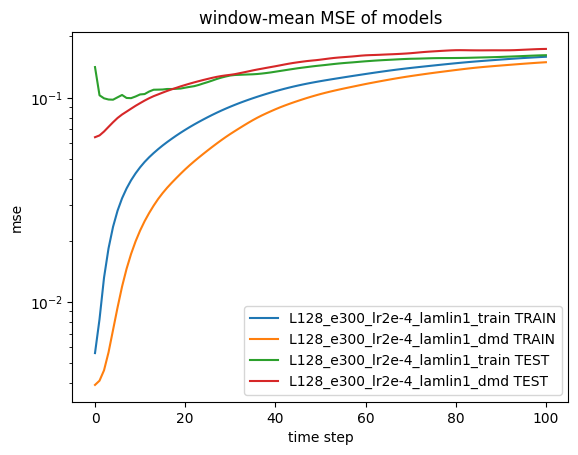

In [285]:
plot_evolution(train_mean_mse + test_mean_mse, train_test_name_list, "window-mean MSE of models", "time step", "mse")

In [286]:
train_mean_mse + test_mean_mse

[array([0.00561873, 0.0082311 , 0.01315693, 0.0183154 , 0.02335164,
        0.02800752, 0.03221261, 0.03599784, 0.03947433, 0.04268965,
        0.04569644, 0.04852581, 0.05115626, 0.05364458, 0.0560684 ,
        0.05844063, 0.0607391 , 0.06300587, 0.06527616, 0.06751971,
        0.06972775, 0.07192154, 0.07407927, 0.07620694, 0.07832346,
        0.08043221, 0.08252143, 0.08458123, 0.08660241, 0.08857888,
        0.09051013, 0.09240538, 0.09426052, 0.09607072, 0.09784277,
        0.09957657, 0.10127475, 0.10294733, 0.10458873, 0.1061937 ,
        0.10776337, 0.10929088, 0.11077325, 0.11220785, 0.11358962,
        0.11491404, 0.11617925, 0.11739208, 0.1185548 , 0.11967476,
        0.12075955, 0.12181359, 0.12284006, 0.12385498, 0.12486756,
        0.12588155, 0.12689463, 0.12790052, 0.12890444, 0.12990482,
        0.13090544, 0.13190346, 0.13289215, 0.13386499, 0.13482474,
        0.13577097, 0.1366983 , 0.13760118, 0.13847639, 0.13932317,
        0.14014085, 0.14093312, 0.14170605, 0.14

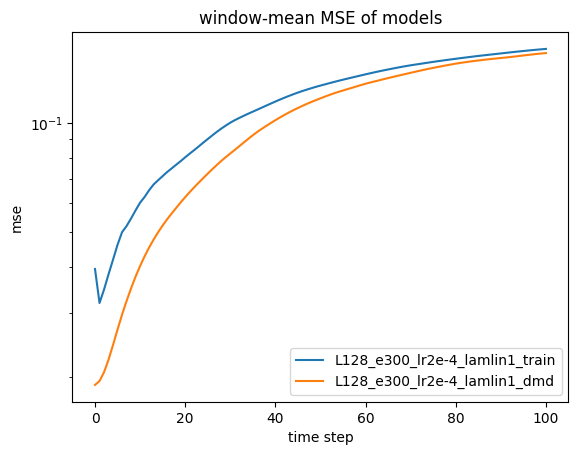

In [287]:
plot_evolution(global_mse_list, run_name_list, "window-mean MSE of models", "time step", "mse")

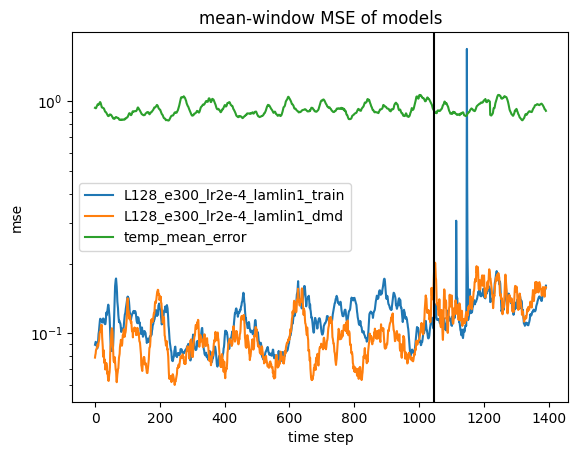

In [288]:
plot_evolution(mean_mse_list+[temp_mean_error[:1393]], run_name_list+["temp_mean_error"], "mean-window MSE of models", "time step", "mse")
plt.vlines(train_test_cutoff, 0, 20, colors=["black"])

In [162]:
mean_mse_list[0][1147]

np.float64(0.20908638790692433)

In [262]:
#1148

In [263]:
temp_mean_error

array([0.9374629 , 0.93512404, 0.9338849 , ..., 1.0869305 , 1.0868763 ,
       1.0821607 ], shape=(1493,), dtype=float32)